# M3 Review Notebook
* Name: Aqeel Alwehimd
* SID: 202005913

## Data Analysis and Visualization – Collated Answer Processing

This notebook documents my contribution to the group project team member 3 (M3), responsible for statistics of responses and visualization of participant behaviour across structured textual data.

The notebook includes:
* Overview
* Assumptions
* Methodology
* Testing strategy using my mock data
* Pattern detection and results
* Limitations (time complexity)
* Reflection and conclusion

## 1) Overview: role and contribution

As the team member 3 (M3) of the group, my responsibility was focused on:
- Parsing and extracting structured collated response data from the collated_answers.txt file
- Computing statistics (mean per question)
- Visualizing both individual and collective response behaviour

No responsibilities were assigned outside this analysis, and my work was developed independently within this task only .

To ensure correctness prior to integration, mock datasets were used to validate logic and statistical computations.

### Prior Code:
If needed: The following code should be run to prepare further code run

In [ ]:
import matplotlib.pyplot as plt
from pyc_testing_files import data_extraction_M1 as m1
from pyc_testing_files import data_preparation_M2 as m2
# You might need to move data_analysis_M3 from /scripts to /review to re-import the module
import importlib
import data_analysis_M3 as m3
importlib.reload(m3)

url = "https://raw.githubusercontent.com/fc-leeds/MATH1604_2025_2026_data/main"
data_folder = "../data"
collated_path = "../output/collated_answers.txt"

for i in range(1, 65):
    m2.download_answer_files(url, data_folder, i)

m2.collate_answer_files(data_folder)

with open(collated_path, 'r') as collated:
    lines = collated.readlines()

## 2) Assumptions: data structure

The dataset consists of multiple participants responses stored in text format.

Each participant block follows this structure:

* A question header: "Question n. text"
* Four possible answers per question
* One selected answer marked with "[X]"
* Questions are repeated up to Question 100
* A "*" symbol separates participants

Example:

Q1. text  
[ ] A1  
[X] A2  
[ ] A3  
[ ] A4  

And this format repeats for all participants in the collated answers file.

### Main assumptions:
* Each participant answers exactly 100 questions
* Each question contains exactly 4 options
* Only one option may be selected per question
* Missing responses are encoded as "0"
* Input formatting is strict and consistent
* Assuming that the functions will each be called on its own, therefore duplicating some logic

## 3) Method

My functionalities are divided into two main parts:

### 3a) Answer Extraction
Each participant block is parsed sequentially. For each question:
* The selected answer is identified via the "[X]" marker
* The index of the selected option (1-4) is recorded as the answer
* If no selection is found, the response is recorded as "0"

### 3b) Grouping
Once all participant responses are extracted:
- A per-question grouping is performed
- Mean response values are computed across participants
- Missing values (0) are excluded from mean calculations

This produces a numerical sequence representing average response per question.

### Note)
The code for my two functions (without comments or docstrings) will be at the end of this report under the Reflection sections for clarity.

## 4) Testing and Validation Strategy

To ensure correctness of parsing and grouping logic, a testing approach was used prior to full dataset release (before 9'th ofApril).

### 4a) Mock Dataset Testing
A simplified synthetic dataset was constructed to simulate:
* Multiple participants
* Random answer distributions

This allowed for the verification of:
* Correct parsing of "[X]" selections
* Proper handling of unanswered questions (encoded as 0)
* Implement computation of mean values per question

### 4b) Wrong-going scenarios
Additional checks were performed on:
* Missing responses (answers encoded as 0)

### 4c) Manual Verification
I selected question No. 1 to confirm the following:
* Extracted answers matched expected indices (which imply correcntess of calculations)
* Mean calculations aligned with hand-derived results

And here are the results for question No. 1 manual calculations:

In [181]:
answers = []
for index in range(0, len(lines), 600):
    checker = 0
    for ind, answer in enumerate(lines[index+1: index+5]):
        if '[X]' in answer:
            answers.append(int(ind+1))
            continue
        else:
            checker += 1
    if checker >= 4:
        answers.append(0)

print("Manual Verification: ", sum(answers)/len(answers))
print("Function's extracted mean: ", m3.generate_means_sequence(collated_path)[0])

Manual Verification:  1.0625
Function's extracted mean:  1.0625


## 5) Pattern Detection and Results

Two visualization approaches were used:

### 5a) Individual Response Patterns
Line plots of individual participants show high variability across questions. Responses do not cluster into stable behavioural patterns, indicating:

* High variance
* Lower "agreement" across questions
* Potential randomness or intended dishonesty in responses OR quiz were generally harder

### 5b) Aggregated Mean Behaviour
The mean response per question reveals a repeating structured pattern across the sequence of questions.

As seen from the visuals below, there as a pattern that goes as follows: a, b, c, d, a, b, c, d, etc. Which indicates a cyclic mean response across participants.  

This suggests one of the following interpretations:
* Possible cyclical structure in question design
* Ordering effects influence response distribution

The presence of periodic structure in aggregated means is noticeable, as it indicates non-uniform distribution of responses across the quiz.

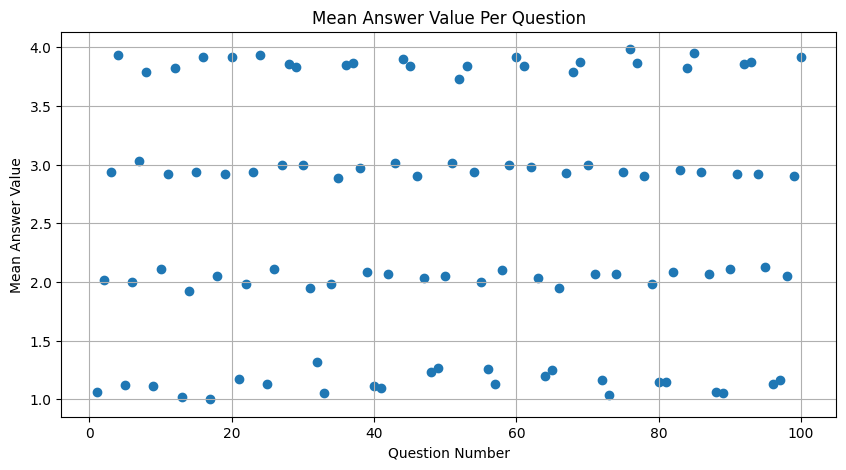

In [182]:
m3.visualize_data('../output/collated_answers.txt', 1)

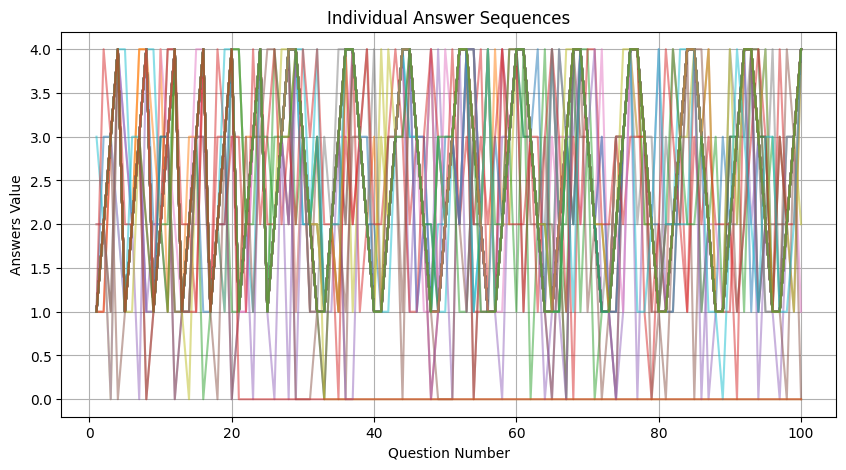

In [183]:
m3.visualize_data("../output/collated_answers.txt", 2)

## 6) Limitations: Computational Complexity (From MATH1013)

Time Complexity: O(PQ)  
Using Big-O notation where:
* P = number of participants
* Q = number of questions per participant  


Referring to what was learned from other modules (MATH1013), the time complexity of our algorithm belongs to the linear big-O family without occurrence of logs or other non-linear functions. This is because the algorithm processes each participant sequentially and iterates through each of their questions once during extraction and grouping. The implementation does not perform operations such as sorting, recursive functions, or repeated comparisons between participants or questions, meaning no logarithmic, quadratic or any other non-linear factors are introduced. As a result, the runtime grows linearly with the total amount of quiz data being processed. My logic is concerning tabular-like data, since I assumed that each question block has 4 answers and I was iterating through them in a deterministic way. Think of qestions as columns, and participants as rows or vice versa, resulting in a 64x100 table of numerical data.

## 7) Reflection and Conclusions

This project provided practical experience in:
* Structured data parsing
* Handling structured textual datasets
* Designing aggregation and grouping pipelines
* Interpreting statistical outputs from raw behavioural and/or textual data

To conclude, a key insight from the analysis is that aggregated behavioural data can reveal structural patterns not visible at the lower level. However, such patterns must be interpreted carefully, as they may arise from dataset design rather than true behavioural signals, such as how we seen individual sequences being messy and might indicate some individuals carelessly or randomly answering questions.

## Original Code Reference

In [186]:
def generate_means_sequence(collated_answers_path):
    def extract_answers(participant):

        answers = []
        for index, line in enumerate(participant):
            if "Question " in line:
                question_group = participant[index+1: index+5]
                checker_iteration = 0

                for smaller_index, answer in enumerate(question_group):
                    if "[X]" in answer:
                        answer_number = smaller_index + 1
                        answers.append(answer_number)
                        break
                    else:
                        checker_iteration += 1

                if checker_iteration >= 4:
                    answers.append(0)
            else:
                continue
        return answers

    with open(collated_answers_path, "r") as coll:
        lines = coll.readlines()

    smaller_groups = []
    individual_list = []

    for index, line in enumerate(lines):
        if line.strip() == "*":
            smaller_groups.append(extract_answers(individual_list))
            individual_list = []
        else:
            individual_list.append(line)

    if individual_list:
        smaller_groups.append(extract_answers(individual_list))
        
    means = []
    for question in range(0, 100):
        question_answers = []
        for individual in smaller_groups:
            answer = individual[question]
            if answer != 0:
                question_answers.append(answer)
        means.append(sum(question_answers)/len(question_answers))        

    return means



def visualize_data(collated_answers_path, n):
    def extract_answers(participant):

        answers = []
        for index, line in enumerate(participant):
            if "Question " in line:
                question_group = participant[index+1: index+5]
                checker_iteration = 0

                for smaller_index, answer in enumerate(question_group):
                    if "[X]" in answer:
                        answer_number = smaller_index + 1
                        answers.append(answer_number)
                        break
                    else:
                        checker_iteration += 1

                if checker_iteration >= 4:
                    answers.append(0)
            else:
                continue

        return answers
        
    with open(collated_answers_path, "r") as coll:
        lines = coll.readlines()

    smaller_groups = []
    individual_list = []

    for index, line in enumerate(lines):
        if line.strip() == "*":
            smaller_groups.append(extract_answers(individual_list))
            individual_list = []
        else:
            individual_list.append(line)

    if individual_list:
        smaller_groups.append(extract_answers(individual_list))

    means = generate_means_sequence(collated_answers_path)

    plt.figure(figsize=(10, 5))
    plt.grid(True)


    if n == 1:
        plt.scatter(range(1, 101), means)
        plt.xlabel("Question Number")
        plt.ylabel("Mean Answer Value")
        plt.title("Meane Answer Value per Question")
        plt.show()
    elif n == 2:

        for answer in smaller_groups:
            plt.plot([i + 1 for i in range(len(answer))], answer, alpha=0.5)
        plt.xlabel("Question Number")
        plt.ylabel("Answers Value")
        plt.title("Individual Answer Sequences")
        plt.show()
    else:
        raise Exception("The second given input (n) should be either 1 or 2")